## Proviamo i modelli per H=0 

### Test preliminare per create_sequence(): risultati coerenti per H=0

In [1]:
import numpy as np
from data_pipeline import *

def test_h0_no_leakage_mechanism(df, look_back=20):
    """Verifica che con H=0 l'ultimo step della finestra X e il target y
    corrispondano esattamente allo stesso giorno (riproduzione del leakage)."""

    feature_columns = [c for c in df.columns if c not in ['Date', 'year', 'Amount of irrigation']]
    X0, y0 = create_sequences(df, look_back, H=0)

    idx = 0
    for year in df['year'].unique():
        year_data = df[df['year'] == year].reset_index(drop=True)
        n = len(year_data)
        for i in range(n - look_back + 1):  # stesso range della funzione con H=0
            last_day_row = year_data.iloc[i + look_back - 1]

            # 1) il target generato == target reale di quel giorno
            assert np.isclose(y0[idx], last_day_row['Amount of irrigation']), f"target mismatch idx={idx}"

            # 2) l'ultimo step della finestra X == feature reali di quel giorno
            assert np.allclose(X0[idx, -1, :], last_day_row[feature_columns].values), f"feature mismatch idx={idx}"

            idx += 1

    assert idx == len(y0), "conteggio campioni non corrisponde"
    print(f"OK: {idx} campioni verificati — H=0 allinea finestra e target sullo stesso giorno")

# carica e prepara i dati come nella pipeline reale
df = load_data('data/data-ready-def.xlsx')
train_df, valid_df, test_df = split_data(df)  #i tre set splittati

train_df_clean = clean_data(train_df)
valid_df_clean = clean_data(valid_df)
test_df_clean = clean_data(test_df)

train_df_norm, valid_df_norm, test_df_norm, train_df_min, train_df_max = normalize(train_df_clean, valid_df_clean, test_df_clean)

# lancia il test su ciascuno split
test_h0_no_leakage_mechanism(train_df_norm, look_back=20)
test_h0_no_leakage_mechanism(valid_df_norm, look_back=20)
test_h0_no_leakage_mechanism(test_df_norm, look_back=20)

OK: 2278 campioni verificati — H=0 allinea finestra e target sullo stesso giorno
OK: 402 campioni verificati — H=0 allinea finestra e target sullo stesso giorno
OK: 402 campioni verificati — H=0 allinea finestra e target sullo stesso giorno


### SETUP H=0

In [8]:
from deep_models import *
from data_pipeline import *
from baselines import *

import random
import numpy as np
import tensorflow as tf

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

#split and clean
df = load_data('data/data-ready-def.xlsx')
train_df, valid_df, test_df = split_data(df)  #i tre set splittati

train_df_clean = clean_data(train_df)
valid_df_clean = clean_data(valid_df)
test_df_clean = clean_data(test_df)

#normalize
train_df_norm, valid_df_norm, test_df_norm, train_df_min, train_df_max = normalize(train_df_clean, valid_df_clean, test_df_clean)

#create_sequence (H = 0)
train_X, train_y = create_sequences(train_df_norm, 20, 0)
valid_X, valid_y = create_sequences(valid_df_norm, 20, 0)
test_X, test_y = create_sequences(test_df_norm, 20, 0)

### Linear Regression e Gradient Boosting

In [ ]:
#non testo le altre 3 funzioni di baseline perché i risultati sono banali o non possono essere calcolati (non usano H)

target_min = train_df_min['Amount of irrigation']
target_max = train_df_max['Amount of irrigation']

lr_valid_mae, lr_valid_rmse, lr_valid_r2, lr_test_mae, lr_test_rmse, lr_test_r2 = fit_and_evaluate(
    LinearRegression(), train_X, train_y, valid_X, valid_y, test_X, test_y, target_min, target_max
)
gb_valid_mae, gb_valid_rmse, gb_valid_r2, gb_test_mae, gb_test_rmse, gb_test_r2 = fit_and_evaluate(
    XGBRegressor(random_state=42), train_X, train_y, valid_X, valid_y, test_X, test_y, target_min, target_max
)

print_metrics("Linear Regression", lr_valid_mae, lr_valid_rmse, lr_valid_r2, lr_test_mae, lr_test_rmse, lr_test_r2)
print_metrics("Gradient Boosting", gb_valid_mae, gb_valid_rmse, gb_valid_r2, gb_test_mae, gb_test_rmse, gb_test_r2)

--- Linear Regression ---
Valid: MAE=0.90583  RMSE=1.24532  R²=0.6958
Test:  MAE=0.90860  RMSE=1.16640  R²=0.7209

--- Gradient Boosting ---
Valid: MAE=0.40570  RMSE=0.63079  R²=0.9219
Test:  MAE=0.39945  RMSE=0.62403  R²=0.9201



### LSTM, CNN e BiLSTM-CNN-Attention

In [9]:

random.seed(42); np.random.seed(42); tf.random.set_seed(42)
lstm = build_lstm_model(train_X.shape[2], train_X.shape[1], lstm_units=64)

lstm_valid_mae, lstm_valid_rmse, lstm_valid_r2, lstm_test_mae, lstm_test_rmse, lstm_test_r2, history = fit_and_evaluate_deep(
    lstm, train_X, train_y, valid_X, valid_y, test_X, test_y, target_min, target_max)

random.seed(42); np.random.seed(42); tf.random.set_seed(42)
cnn = build_cnn_model(train_X.shape[2], train_X.shape[1], filters=64)

cnn_valid_mae, cnn_valid_rmse, cnn_valid_r2, cnn_test_mae, cnn_test_rmse, cnn_test_r2, history = fit_and_evaluate_deep(
    cnn, train_X, train_y, valid_X, valid_y, test_X, test_y, target_min, target_max)


random.seed(42); np.random.seed(42); tf.random.set_seed(42)
bilstm = build_bilstm_cnn_attention_model(train_X.shape[2], train_X.shape[1], lstm_units=64)

bilstm_cnn_attn_valid_mae, bilstm_cnn_attn_valid_rmse, bilstm_cnn_attn_valid_r2, bilstm_cnn_attn_test_mae, bilstm_cnn_attn_test_rmse, bilstm_cnn_attn_test_r2, history = fit_and_evaluate_deep(
    bilstm, train_X, train_y, valid_X, valid_y, test_X, test_y, target_min, target_max)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0285 - val_loss: 0.0271
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0240 - val_loss: 0.0232
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0206 - val_loss: 0.0187
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0175 - val_loss: 0.0181
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0139 - val_loss: 0.0129
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0119 - val_loss: 0.0116
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0114 - val_loss: 0.0113
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0108 - val_loss: 0.0110
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0106 - val_loss: 0.0108
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0103 - val_loss: 0.0105
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0101 - val_loss: 0.0103
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step 

In [11]:
#risultati test

import pandas as pd
import os

results_h0 = pd.DataFrame([
    {'model': 'Linear Regression', 'mae_valid': lr_valid_mae, 'rmse_valid': lr_valid_rmse, 'r2_valid': lr_valid_r2,
     'mae_test': lr_test_mae, 'rmse_test': lr_test_rmse, 'r2_test': lr_test_r2},
    {'model': 'Gradient Boosting', 'mae_valid': gb_valid_mae, 'rmse_valid': gb_valid_rmse, 'r2_valid': gb_valid_r2,
     'mae_test': gb_test_mae, 'rmse_test': gb_test_rmse, 'r2_test': gb_test_r2},
    {'model': 'LSTM', 'mae_valid': lstm_valid_mae, 'rmse_valid': lstm_valid_rmse, 'r2_valid': lstm_valid_r2,
     'mae_test': lstm_test_mae, 'rmse_test': lstm_test_rmse, 'r2_test': lstm_test_r2},
    {'model': 'CNN', 'mae_valid': cnn_valid_mae, 'rmse_valid': cnn_valid_rmse, 'r2_valid': cnn_valid_r2,
     'mae_test': cnn_test_mae, 'rmse_test': cnn_test_rmse, 'r2_test': cnn_test_r2},
    {'model': 'BiLSTM-CNN-Attention', 'mae_valid': bilstm_cnn_attn_valid_mae, 'rmse_valid': bilstm_cnn_attn_valid_rmse, 'r2_valid': bilstm_cnn_attn_valid_r2,
     'mae_test': bilstm_cnn_attn_test_mae, 'rmse_test': bilstm_cnn_attn_test_rmse, 'r2_test': bilstm_cnn_attn_test_r2},
])

os.makedirs('results', exist_ok=True)
results_h0.to_csv('results/trick_test_H0.csv', index=False)
results_h0

,model,mae_valid,rmse_valid,r2_valid,mae_test,rmse_test,r2_test
0,Linear Regression,0.905827,1.245323,0.695774,0.908598,1.166400,0.720853
1,Gradient Boosting,0.405698,0.630787,0.921946,0.399447,0.624028,0.920100
2,LSTM,0.297273,0.455129,0.959365,0.307300,0.473704,0.953958
3,CNN,0.497531,0.662696,0.913849,0.486366,0.665927,0.909010
4,BiLSTM-CNN-Attention,0.403517,0.653273,0.916281,0.390295,0.610268,0.923585


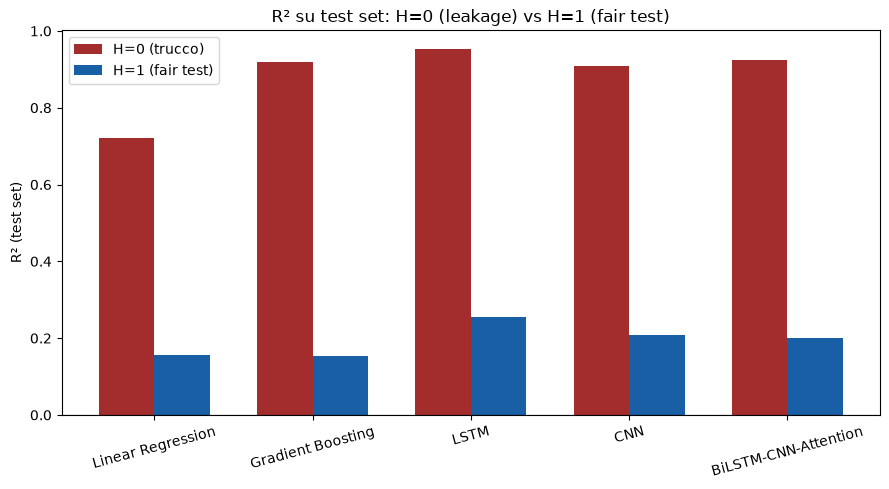

In [ ]:
#questo è il test che confronta H=0 e H=1 e che genera il plot

import pandas as pd
import matplotlib.pyplot as plt
import os

h0 = pd.read_csv('results/trick_test_H0.csv')

h1_deep = pd.read_csv('results/deep_models_H1.csv')
h1_base = pd.read_csv('results/baselines_H1.csv')
h1_base = h1_base[h1_base['baseline'].isin(['Linear regression', 'Gradient boosting'])].rename(columns={'baseline': 'model'})

# attenzione: nei due file la capitalizzazione dei nomi modello è diversa
# ('Linear regression' in baselines_H1.csv vs 'Linear Regression' in trick_test_H0.csv) — uniformo
rename_map = {'Linear regression': 'Linear Regression', 'Gradient boosting': 'Gradient Boosting'}
h1_base['model'] = h1_base['model'].replace(rename_map)

h1 = pd.concat([h1_base[['model', 'r2_test']], h1_deep[['model', 'r2_test']]], ignore_index=True)

model_order = ['Linear Regression', 'Gradient Boosting', 'LSTM', 'CNN', 'BiLSTM-CNN-Attention']
h0_r2 = h0.set_index('model').loc[model_order, 'r2_test']
h1_r2 = h1.set_index('model').loc[model_order, 'r2_test']

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(model_order))
width = 0.35

ax.bar([i - width/2 for i in x], h0_r2, width, label='H=0 (trucco)', color='#A32D2D')
ax.bar([i + width/2 for i in x], h1_r2, width, label='H=1 (fair test)', color='#185FA5')

ax.set_xticks(list(x))
ax.set_xticklabels(model_order, rotation=15)
ax.set_ylabel('R² (test set)')
ax.set_title('R² su test set: H=0 (leakage) vs H=1 (fair test)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig1_h0_vs_h1.png', dpi=300, bbox_inches='tight')
plt.show()